# Problem Set 1
## Sagar Clemensen (fck916)
### 11/2-2026

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Problem 1

In [86]:
# dfs_14 = pd.read_html("kenpom_2014.html")
# df_14 = dfs_14[0]   # usually the main table
# df_14

In [87]:
dfs_14 = pd.read_html("kenpom_2014.html", header=17)
df_14 = dfs_14[0]   # usually the main table
df_14

,Rk,Team,Conf,W-L,NetRtg,ORtg,ORtg.1,DRtg,DRtg.1,AdjT,...,Luck,Luck.1,NetRtg.1,NetRtg.2,ORtg.2,ORtg.3,DRtg.2,DRtg.3,NetRtg.3,NetRtg.4
0,1,Louisville 4,Amer,31-6,+30.41,118.9,7,88.5,5,67.2,...,-.045,278,+4.31,95,107.0,100,102.7,93,-4.65,295
1,2,Arizona 1,P12,33-5,+30.11,116.5,20,86.4,1,62.8,...,+.014,151,+9.30,17,109.9,20,100.6,18,+1.62,113
2,3,Florida 1,SEC,36-3,+28.57,116.5,19,88.0,3,61.3,...,+.053,68,+9.02,22,109.4,32,100.4,14,+2.39,94
3,4,Virginia 1,ACC,30-7,+26.46,114.8,27,88.3,4,59.5,...,+.012,154,+8.67,28,109.4,31,100.8,27,+1.57,114
4,5,Wisconsin 2,B10,30-8,+25.89,122.0,4,96.1,35,62.4,...,+.019,133,+11.44,3,110.2,13,98.8,2,+3.33,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,347,Mississippi Valley St.,SWAC,9-23,-22.93,93.0,338,115.9,335,70.9,...,+.012,156,-8.65,338,98.8,346,107.4,257,+6.21,35
363,348,Abilene Christian,Slnd,11-20,-23.35,94.0,330,117.3,342,63.2,...,-.045,279,-2.67,211,104.7,159,107.4,256,+13.38,4
364,349,Presbyterian,BSth,6-26,-25.87,94.2,328,120.0,349,63.5,...,-.017,221,-7.84,324,101.7,307,109.6,326,-7.05,328
365,350,Grambling St.,SWAC,5-24,-26.60,95.5,316,122.1,351,66.0,...,-.017,220,-9.05,342,98.7,348,107.8,269,+6.51,31


In [88]:
df_14["Rk"] = pd.to_numeric(df_14["Rk"], errors="coerce")
df_14 = df_14.dropna(subset=["Rk"]).reset_index(drop=True)
df_14

,Rk,Team,Conf,W-L,NetRtg,ORtg,ORtg.1,DRtg,DRtg.1,AdjT,...,Luck,Luck.1,NetRtg.1,NetRtg.2,ORtg.2,ORtg.3,DRtg.2,DRtg.3,NetRtg.3,NetRtg.4
0,1.0,Louisville 4,Amer,31-6,+30.41,118.9,7,88.5,5,67.2,...,-.045,278,+4.31,95,107.0,100,102.7,93,-4.65,295
1,2.0,Arizona 1,P12,33-5,+30.11,116.5,20,86.4,1,62.8,...,+.014,151,+9.30,17,109.9,20,100.6,18,+1.62,113
2,3.0,Florida 1,SEC,36-3,+28.57,116.5,19,88.0,3,61.3,...,+.053,68,+9.02,22,109.4,32,100.4,14,+2.39,94
3,4.0,Virginia 1,ACC,30-7,+26.46,114.8,27,88.3,4,59.5,...,+.012,154,+8.67,28,109.4,31,100.8,27,+1.57,114
4,5.0,Wisconsin 2,B10,30-8,+25.89,122.0,4,96.1,35,62.4,...,+.019,133,+11.44,3,110.2,13,98.8,2,+3.33,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,347.0,Mississippi Valley St.,SWAC,9-23,-22.93,93.0,338,115.9,335,70.9,...,+.012,156,-8.65,338,98.8,346,107.4,257,+6.21,35
347,348.0,Abilene Christian,Slnd,11-20,-23.35,94.0,330,117.3,342,63.2,...,-.045,279,-2.67,211,104.7,159,107.4,256,+13.38,4
348,349.0,Presbyterian,BSth,6-26,-25.87,94.2,328,120.0,349,63.5,...,-.017,221,-7.84,324,101.7,307,109.6,326,-7.05,328
349,350.0,Grambling St.,SWAC,5-24,-26.60,95.5,316,122.1,351,66.0,...,-.017,220,-9.05,342,98.7,348,107.8,269,+6.51,31


In [89]:
# subset = df.iloc[:, [0, 1, 2, 7]]
subset_14 = df_14[["Rk", "Team", "Conf", "DRtg"]]
subset_14

,Rk,Team,Conf,DRtg
0,1.0,Louisville 4,Amer,88.5
1,2.0,Arizona 1,P12,86.4
2,3.0,Florida 1,SEC,88.0
3,4.0,Virginia 1,ACC,88.3
4,5.0,Wisconsin 2,B10,96.1
...,...,...,...,...
346,347.0,Mississippi Valley St.,SWAC,115.9
347,348.0,Abilene Christian,Slnd,117.3
348,349.0,Presbyterian,BSth,120.0
349,350.0,Grambling St.,SWAC,122.1


In [90]:
conference_14 = subset_14["Conf"].values
DRtg = subset_14["DRtg"].values
DRtg_list = {}
conferences_list = ["ACC", "SEC", "B10", "BSky", "A10", "BE"]
for conf in conferences_list:
    DRtg_list[conf] = np.array(DRtg[conference_14 == conf], dtype=float)

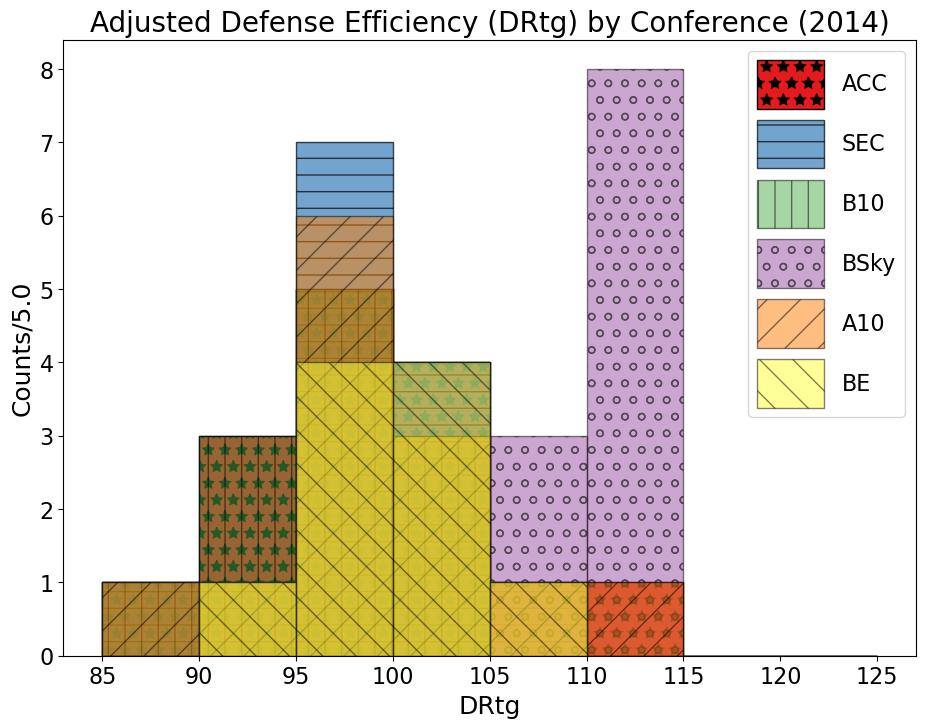

In [91]:
colors = plt.cm.Set1.colors
xmin = 85
xmax = 125
Nbins = 8
binwidth = (xmax - xmin) / Nbins
hatches = ['*', '-', '|', 'o', '/', '\\']
alphas = [1, 0.7, 0.5, 0.5, 0.5, 0.5]
fig, ax = plt.subplots(figsize=(11, 8))
for i, conf in enumerate(conferences_list):
    ax.hist(DRtg_list[conf], bins=Nbins, range=(xmin, xmax), color=colors[i], label=conferences_list[i], hatch = hatches[i], alpha=alphas[i], edgecolor='black', linewidth=1)
ax.set_xlabel("DRtg", fontsize=18)
ax.set_ylabel(f"Counts/{binwidth}", fontsize=18)
ax.set_title("Adjusted Defense Efficiency (DRtg) by Conference (2014)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(handlelength=3, handleheight=3, fontsize=16);

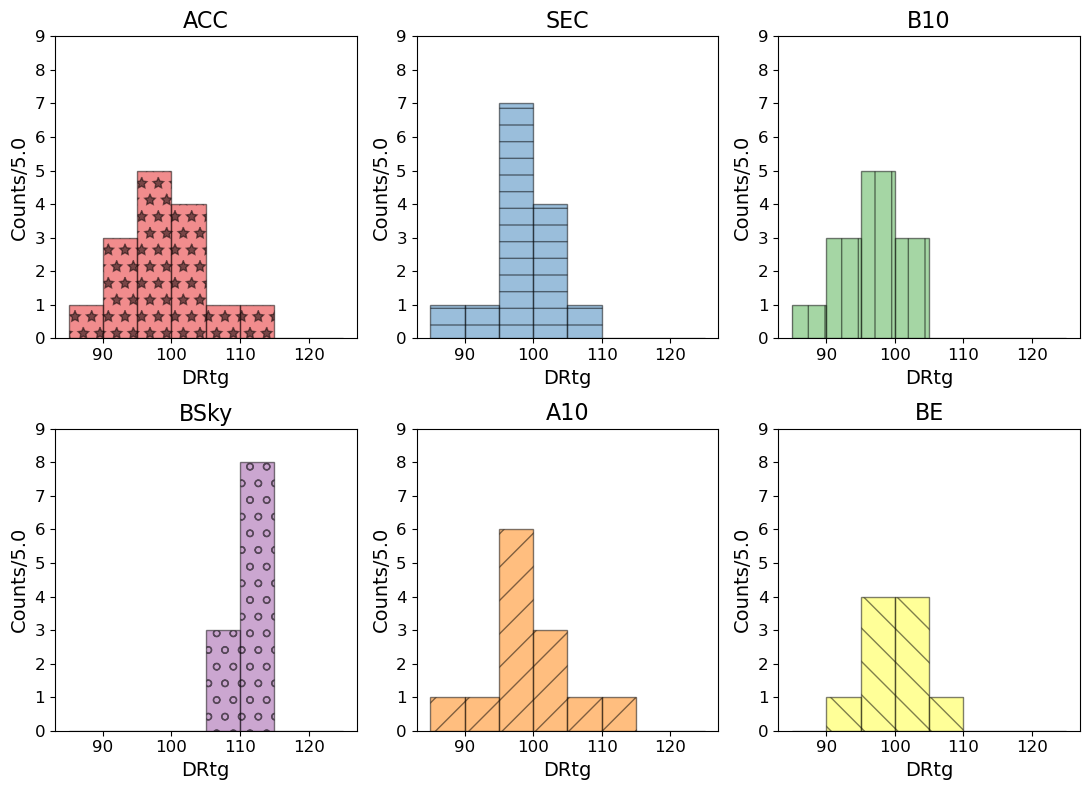

In [92]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(11, 8))
axs = axs.flatten()
for i, conf in enumerate(conferences_list):
    axs[i].hist(DRtg_list[conf], bins=Nbins, range=(xmin, xmax), color=colors[i], label=conferences_list[i], hatch = hatches[i], alpha=0.5, edgecolor='black', linewidth=1)
    axs[i].set_title(conferences_list[i], fontsize=16)
    axs[i].set_xlabel("DRtg", fontsize=14)
    axs[i].set_ylabel(f"Counts/{binwidth}", fontsize=14)
    axs[i].set_ylim(0, 9)
    axs[i].tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()

## Problem 2

In [93]:
dfs_9 = pd.read_html("kenpom_2009.html", header=17)
df_9 = dfs_9[0]   # usually the main table
df_9["Rk"] = pd.to_numeric(df_9["Rk"], errors="coerce")
df_9 = df_9.dropna(subset=["Rk"]).reset_index(drop=True)
df_9

,Rk,Team,Conf,W-L,NetRtg,ORtg,ORtg.1,DRtg,DRtg.1,AdjT,...,Luck,Luck.1,NetRtg.1,NetRtg.2,ORtg.2,ORtg.3,DRtg.2,DRtg.3,NetRtg.3,NetRtg.4
0,1.0,North Carolina 1,ACC,34-4,+31.14,123.2,1,92.1,18,72.9,...,-.011,195,+9.91,24,108.2,27,98.3,15,+1.06,126
1,2.0,Connecticut 1,BE,31-5,+29.25,116.0,17,86.8,3,67.1,...,+.024,107,+10.37,13,109.0,11,98.6,24,-1.68,200
2,3.0,Pittsburgh 1,BE,31-5,+28.96,121.2,2,92.3,19,65.2,...,-.012,201,+10.11,19,108.1,28,98.0,12,+0.79,132
3,4.0,Memphis 2,CUSA,33-4,+28.67,112.8,37,84.2,1,65.9,...,-.009,190,+4.73,77,105.5,73,100.8,78,+4.19,67
4,5.0,Louisville 1,BE,31-6,+26.06,111.2,49,85.2,2,66.9,...,+.068,25,+9.57,27,108.6,17,99.0,37,-0.19,161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,340.0,Alcorn St.,SWAC,6-25,-26.40,92.1,313,118.5,344,72.4,...,-.050,296,-10.26,331,96.5,331,106.7,325,+2.94,92
340,341.0,Grambling St.,SWAC,6-23,-27.10,89.8,330,116.9,343,61.8,...,-.015,210,-10.00,330,96.6,329,106.6,320,+4.77,56
341,342.0,Maryland Eastern Shore,MEAC,7-23,-27.77,89.2,336,116.9,342,63.5,...,+.060,34,-12.24,343,93.7,344,105.9,298,-9.51,332
342,343.0,North Carolina Central,ind,4-27,-28.86,85.6,342,114.5,338,69.0,...,-.015,212,-4.55,261,100.0,273,104.5,229,+5.90,41


In [94]:
conference_9 = df_9["Conf"].values
teams_9 = df_9["Team"].values
ORtg_9 = df_9["ORtg"].values
ORtg_14 = df_14["ORtg"].values
teams_14 = df_14["Team"].values

In [95]:
import re

# data['Team'] = data['Team'].str.strip("0123456789 ")
# data_2009['Team'] = data_2009['Team'].str.strip("0123456789 ")

# common_teams = data_2009[data_2009['Team'].isin(data['Team'])]

teams_9_cleaned = [re.sub(r'\s*\d+$', '', team) for team in teams_9]
teams_14_cleaned = [re.sub(r'\s*\d+$', '', team) for team in teams_14]

only_in_9 = [x for x in teams_9_cleaned if x not in teams_14_cleaned]
only_in_14 = [x for x in teams_14_cleaned if x not in teams_9_cleaned]
print("In NCAA 2009 but not 2014:", only_in_9)
print("In NCAA 2014 but not 2009:", only_in_14)

common_teams = set(teams_9_cleaned) & set(teams_14_cleaned)
print("Amount of teams in both years:", len(common_teams))

teams_9_filtered = [team for team in teams_9_cleaned if team in common_teams]
teams_14_filtered = [team for team in teams_14_cleaned if team in common_teams]

In NCAA 2009 but not 2014: ['Centenary', 'Winston Salem St.']
In NCAA 2014 but not 2009: ['Nebraska Omaha', 'Seattle', 'Grand Canyon', 'South Dakota', 'Incarnate Word', 'North Dakota', 'Northern Kentucky', 'UMass Lowell', 'Abilene Christian']
Amount of teams in both years: 342


In [96]:
ORtg9_prim = {conf: np.array([], float) for conf in conferences_list}
ORtg14_prim = {conf: np.array([], float) for conf in conferences_list}
ORtg9_other = np.array([], float)
ORtg14_other = np.array([], float)
teams9_prim = {conf: [] for conf in conferences_list}
teams14_prim = {conf: [] for conf in conferences_list}


for team in common_teams:
    conf9 = conference_9[teams_9_cleaned.index(team)]
    conf14 = conference_14[teams_14_cleaned.index(team)]
    if conf9 in conferences_list and conf9==conf14:
        # teams9_prim[conf9].append(team)
        # teams14_prim[conf14].append(team)
        ORtg9_prim[conf9] = np.append(ORtg9_prim[conf9], float(ORtg_9[teams_9_cleaned.index(team)]))
        ORtg14_prim[conf14] = np.append(ORtg14_prim[conf14], float(ORtg_14[teams_14_cleaned.index(team)]))
    else:
        ORtg9_other = np.append(ORtg9_other, float(ORtg_9[teams_9_cleaned.index(team)]))
        ORtg14_other = np.append(ORtg14_other, float(ORtg_14[teams_14_cleaned.index(team)]))

ORtg_diff_prim = {}

for conf in conferences_list:
    ORtg_diff_prim[conf] = ORtg14_prim[conf] - ORtg9_prim[conf]
    
ORtg_diff_other = ORtg14_other - ORtg9_other

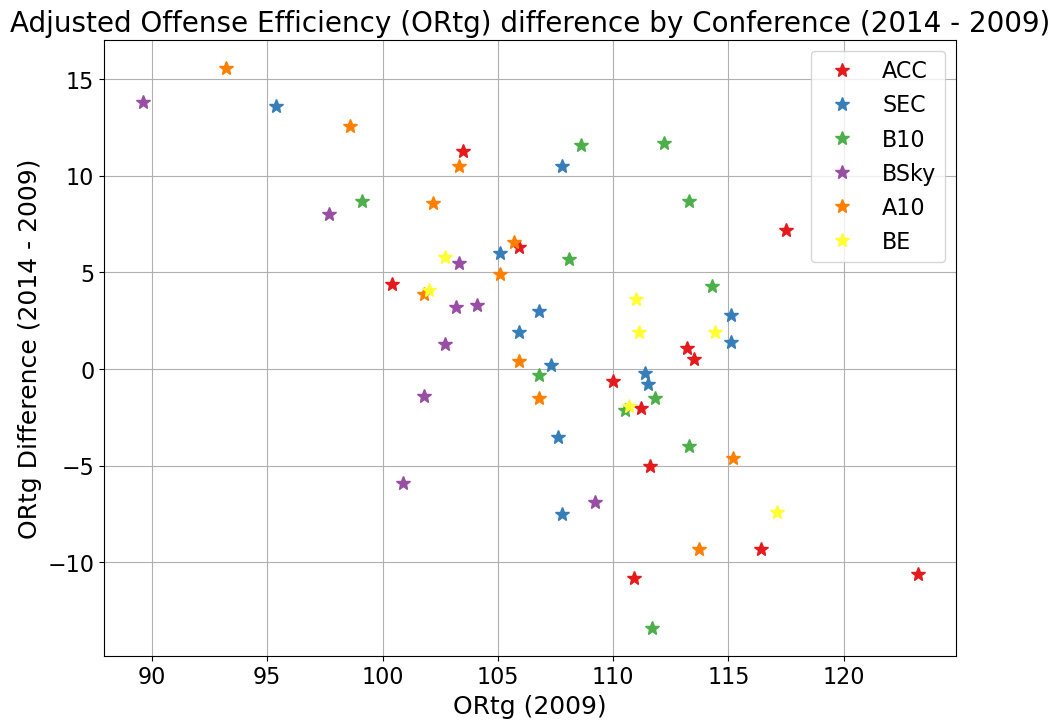

In [97]:
colors = plt.cm.Set1.colors
fig, ax = plt.subplots(figsize=(11, 8))
for i, conf in enumerate(conferences_list):
    ax.plot(ORtg9_prim[conf], ORtg_diff_prim[conf], '*', color=colors[i], label=conferences_list[i], markersize=10)
ax.set_xlabel("ORtg (2009)", fontsize=18)
ax.set_ylabel("ORtg Difference (2014 - 2009)", fontsize=18)
ax.set_title("Adjusted Offense Efficiency (ORtg) difference by Conference (2014 - 2009)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid()
ax.legend(fontsize=16);

In [98]:
for conf in conferences_list:
    diff = ORtg_diff_prim[conf]
    mean = np.mean(diff)
    median = np.median(diff)
    print(f"{conf} - mean diff: {mean:.4f}, and  median diff: {median:.4f}")

ACC - mean diff: -0.6250, and  median diff: -0.0500
SEC - mean diff: 2.2833, and  median diff: 1.6500
B10 - mean diff: 2.6727, and  median diff: 4.3000
BSky - mean diff: 2.3222, and  median diff: 3.2000
A10 - mean diff: 4.3364, and  median diff: 4.9000
BE - mean diff: 1.1429, and  median diff: 1.9000


In [99]:
mean_other = np.mean(ORtg_diff_other)
median_other = np.median(ORtg_diff_other)
print(f"Other Conferences - mean diff: {mean_other:.4f}, and median diff: {median_other:.4f} ")

Other Conferences - mean diff: 2.4132, and median diff: 1.3000 


In [100]:
all_conf = np.unique(conference_14)
other_conf = [conf for conf in all_conf if conf not in conferences_list]
print("Amount of other conferences:", len(other_conf))
print("Teams in primary confs", sum(len(v) for v in ORtg14_prim.values()), sum(len(v) for v in ORtg9_prim.values()))
print("Teams in other confs", len(ORtg14_other), len(ORtg9_other))
print("Sum of teams in primary confs and others", len(ORtg14_other) + sum(len(v) for v in ORtg14_prim.values()), "Total amount of common teams", len(common_teams))

Amount of other conferences: 27
Teams in primary confs 62 62
Teams in other confs 280 280
Sum of teams in primary confs and others 342 Total amount of common teams 342


## Extra credit

In [101]:
import pdfplumber
from pdfplumber.utils import extract_text

In [102]:
# The top part of the pdf is not a part of the actual authors on the project, it has a different font size and can thus be eliminated.
with pdfplumber.open("AuthorList.pdf") as pdf:
    all_text = []
    fontsizes = []
    for page in pdf.pages:
        all_text.append(page.extract_text() or "")
        fontsizes.append([char['size'] for char in page.chars])
    full_text = "\n".join(all_text)

In [103]:
# print(full_text)
# print(len(full_text))

In [104]:
all_fontsizes = []
for fonts_per_page in fontsizes:
    all_fontsizes.extend(fonts_per_page)

unique_fontsizes = np.unique(np.round(all_fontsizes, 10))
print("Unique font sizes in the document:", unique_fontsizes)
# There are 5 unique font sizes.

# for size in unique_fontsizes:
#     print(f"\nText with font size {size}:")
#     for page in pdf.pages:
#         page_text = ""
#         for char in page.chars:
#             if np.isclose(char['size'], size):
#                 page_text += char['text']
#         if page_text:
#             print(page_text)

Unique font sizes in the document: [ 5.9768  6.9729  7.9702  9.9626 10.4607]


In [105]:
# Since we are only interested in the authors, we can choose to only keep text with fontsize 9.9626. 
# Even though the group names are a different fontsize they also show up in the list of authors, so we can keep them as well and remove them later.
author_fontsizes = unique_fontsizes[3]

group_fontsize = unique_fontsizes[4]

with pdfplumber.open("AuthorList.pdf") as pdf:
    author_text = []
    group_text = []
    for page in pdf.pages:
        author_chars = [ch for ch in page.chars if np.any(np.isclose(ch["size"], author_fontsizes, atol = 0.5))]
        author_text.append(extract_text(author_chars))
        group_chars = [ch for ch in page.chars if np.isclose(ch["size"], group_fontsize)]
        group_text.append(extract_text(group_chars))

authors = "\n".join(author_text)
groups = "\n".join(group_text)
# print("Authors:\n", authors)
# print("\n Groups \n", groups)

In [106]:
# Extract only group names from group:
group_lines = groups.splitlines()
group_df = pd.DataFrame(group_lines, columns=["Group"])
# Remove any extra commas:
group_df["Group"] = group_df["Group"].str.strip(",")
# Keep only rows that contain at least one letter:
group_df = group_df[group_df["Group"].str.contains(r"[A-Za-z]", regex=True, na=False)]
# Remove rows where the entry is only "and" (ignoring case/whitespace):
group_df = group_df[~group_df["Group"].str.strip().str.fullmatch(r"and", case=False, na=False)]
group_df = group_df.reset_index(drop=True)
group_df

,Group
0,(LIGO Scientific Collaboration and Virgo Colla...
1,(Fermi GBM)
2,(INTEGRAL)
3,(IceCube Collaboration)
4,(AstroSat Cadmium Zinc Telluride Imager Team)
5,(IPN Collaboration)
6,(The Insight-Hxmt Collaboration)
7,(ANTARES Collaboration)
8,(The Swift Collaboration)
9,(AGILE Team)


In [107]:
# Seperate each author by commas, and make a dataframe:
def split_outside_paren(text):
    out = []
    buf = []
    depth = 0
    for ch in str(text):
        if ch == "(":
            depth += 1
        elif ch == ")" and depth > 0:
            depth -= 1
        if ch == "," and depth == 0:
            out.append("".join(buf))
            buf = []
        else:
            buf.append(ch)
    out.append("".join(buf))
    return out

authors_raw = split_outside_paren(authors.replace("\n", ","))
authors_df = pd.DataFrame(authors_raw, columns=["Author"])
authors_df["Author"] = authors_df["Author"].str.strip()
mask = authors_df["Author"].isin(group_df["Group"])
authors_df_group = authors_df[mask]
man_remov_groups = group_df[~group_df["Group"].isin(authors_df_group["Author"])]
names_to_remove = man_remov_groups["Group"].tolist()
print("Names to remove:", names_to_remove)

authors_df = authors_df[~mask]
authors_df

Names to remove: ['(ePESSTO) ']


,Author
0,B.P.Abbott
1,R.Abbott
2,T.D.Abbott
3,F.Acernese
4,K.Ackley
...,...
4225,O. M. Smirnov
4226,
4227,R. P. Fender
4228,and P. A. Woudt


In [108]:
# One of the group names is still in the list of authors, so we can remove it manually
manual_names = ['(ePESSTO)']
mask_manual = authors_df["Author"].isin(manual_names)
authors_df = authors_df[~mask_manual]
authors_df

,Author
0,B.P.Abbott
1,R.Abbott
2,T.D.Abbott
3,F.Acernese
4,K.Ackley
...,...
4225,O. M. Smirnov
4226,
4227,R. P. Fender
4228,and P. A. Woudt


In [109]:
# Remove "and", and so on.
# If an entry starts with "and", split it into its own row, and also split on newlines:
authors_df["Author"] = (
    authors_df["Author"]
      .str.replace(r"\n+", ",", regex=True)
      .str.strip()
      .str.replace(r"^\s*and\b\s*", "and, ", regex=True)
      .str.split(",")
)
authors_df = authors_df.explode("Author")
authors_df["Author"] = authors_df["Author"].str.strip()
authors_df = authors_df[authors_df["Author"].ne("")]

# Remove rows where the entry is only only numbers:
authors_df = authors_df[~authors_df["Author"].str.fullmatch(r"\d+", na=False)]
# Remove any lone "and"s: 
authors_df = authors_df[~authors_df["Author"].str.fullmatch(r"and", case=False, na=False)]
# Remove spaces after periods:
authors_df["Author"] = authors_df["Author"].str.replace(r"\.\s+", ".", regex=True)
authors_df = authors_df.reset_index(drop=True)
authors_df

/var/folders/q_/7x2w9vl95gjddqnzc20k_7sr0000gp/T/ipykernel_18466/3159884850.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  authors_df["Author"] = (


,Author
0,B.P.Abbott
1,R.Abbott
2,T.D.Abbott
3,F.Acernese
4,K.Ackley
...,...
3609,S.Makhathini
3610,N.Oozeer
3611,O.M.Smirnov
3612,R.P.Fender


In [110]:
author_list = authors_df["Author"].tolist()
print(author_list)
uniq_auth_df = pd.DataFrame(author_list, columns=["Unique Authors"])

def split_last_initials(name):
    text = str(name).strip()
    if " " in text:
        parts = text.split()
        last = parts[-1]
        initials = " ".join(parts[:-1])
    elif "." in text:
        last = text.split(".")[-1]
        initials = text[: -(len(last) + 1)]
    else:
        last = text
        initials = ""
    return pd.Series([last, initials])

uniq_auth_df[["_last", "_initials"]] = uniq_auth_df["Unique Authors"].apply(split_last_initials)
uniq_auth_df = uniq_auth_df.sort_values(["_last", "_initials", "Unique Authors"])
uniq_auth_df = uniq_auth_df.drop(columns=["_last", "_initials"]).reset_index(drop=True)
uniq_auth_df


['B.P.Abbott', 'R.Abbott', 'T.D.Abbott', 'F.Acernese', 'K.Ackley', 'C.Adams', 'T.Adams', 'P.Addesso', 'R.X.Adhikari', 'V.B.Adya', 'C.Affeldt', 'M.Afrough', 'B.Agarwal', 'M.Agathos', 'K.Agatsuma', 'N.Aggarwal', 'O.D.Aguiar', 'L.Aiello', 'A.Ain', 'P.Ajith', 'B.Allen', 'G.Allen', 'A.Allocca', 'P.A.Altin', 'A.Amato', 'A.Ananyeva', 'S.B.Anderson', 'W.G.Anderson', 'S.V.Angelova', 'S.Antier', 'S.Appert', 'K.Arai', 'M.C.Araya', 'J.S.Areeda', 'N.Arnaud', 'K.G.Arun', 'S.Ascenzi', 'G.Ashton', 'M.Ast', 'S.M.Aston', 'P.Astone', 'D.V.Atallah', 'P.Aufmuth', 'C.Aulbert', 'K.AultONeal', 'C.Austin', 'A.Avila-Alvarez', 'S.Babak', 'P.Bacon', 'M.K.M.Bader', 'S.Bae', 'P.T.Baker', 'F.Baldaccini', 'G.Ballardin', 'S.W.Ballmer', 'S.Banagiri', 'J.C.Barayoga', 'S.E.Barclay', 'B.C.Barish', 'D.Barker', 'K.Barkett', 'F.Barone', 'B.Barr', 'L.Barsotti', 'M.Barsuglia', 'D.Barta', 'S.D.Barthelmy', 'J.Bartlett', 'I.Bartos', 'R.Bassiri', 'A.Basti', 'J.C.Batch', 'M.Bawaj', 'J.C.Bayley', 'M.Bazzan', 'B.Bécsy', 'C.Beer', 'M.

,Unique Authors
0,A.Aab
1,M.G.Aartsen
2,B.P.Abbott
3,R.Abbott
4,T.D.Abbott
...,...
3609,J.D.Álvarez
3610,R.Šmída
3611,J.Šupík
3612,A.F.Żarnecki


In [113]:
print(f"Number of unique authors: {len(uniq_auth_df)}")

Number of unique authors: 3614


In [118]:
3614//2

1807

## Midpoint author(s)

In [ ]:
uniq_auth_df
median_authors = [uniq_auth_df["Unique Authors"].iloc[len(uniq_auth_df) // 2 - 1],uniq_auth_df["Unique Authors"].iloc[len(uniq_auth_df) // 2]]
print("Median authors:", median_authors)

Median authors: ['K.Link', 'S.D.Linker']
